In [1]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int

from plotly_utils import (
    imshow,
    line
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions
import tempfile

# Load CovFit model

In [4]:
MODEL_PATH = "TheSatoLab-UTokyo/CoVFit"
FOLD_IDS_TO_USE = [0]
TARGET_FOLD_ID = 0
OUTPUT_PREFIX = "inference_results"
model_name = "facebook/esm2_t33_650M_UR50D"

device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [5]:
def download_hf_checkpoints(repo_id, fold_ids):
    """
    Download specified fold checkpoint files from Hugging Face
    Hugging Faceから指定されたfoldのckptファイルをダウンロード
    
    Note: The model repository is public, so no token is required.
    注意：モデルリポジトリは公開されているため、トークンは不要です。
    """
    print(f"Downloading checkpoints from {repo_id} for folds: {fold_ids}")
    model_paths = []
    temp_dir = tempfile.mkdtemp()
    
    try:
        for fold_id in fold_ids:
            filename = f"covfit_model_20231102_{fold_id}.ckpt"
            print(f"Downloading {filename}...")
            
            # Download (no token needed for public repository)
            # ダウンロード（公開リポジトリのためトークン不要）
            downloaded_path = hf_hub_download(
                repo_id=repo_id,
                filename=filename,
                cache_dir=temp_dir
            )
            model_paths.append(downloaded_path)
            
        print(f"Successfully downloaded {len(model_paths)} checkpoint files")
        return model_paths, temp_dir
        
    except Exception as e:
        # Clean up temporary directory on failure
        # 失敗時はテンポラリディレクトリをクリーンアップ
        shutil.rmtree(temp_dir, ignore_errors=True)
        raise e

In [6]:
model_paths, temp_dir = download_hf_checkpoints(
    repo_id=MODEL_PATH,
    fold_ids=FOLD_IDS_TO_USE
)

task_dict_path = hf_hub_download(
    repo_id=MODEL_PATH,
    filename="task_id_dict.pt"
)

checkpoint = torch.load(model_paths[0], map_location=device)
final_weights = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint

original_task_id_infos = torch.load(task_dict_path, map_location=device)
n_targets_original = len(original_task_id_infos)

model_config = ModelConfig()
model_config.da_model_name = model_name

model = load_model_for_inference(model_paths[0], model_config, n_targets_original)
esm_fine_tuned = model.merge_and_unload() #merge PEFT adapter model with the base model and make a fully new model

# dumb thing to make hooked esm and this esm agree
esm_fine_tuned.esm.embeddings.token_dropout = False

# clean up after installing
if temp_dir and os.path.exists(temp_dir):
    shutil.rmtree(temp_dir, ignore_errors=True)
    print("Temporary files cleaned up")

covfit_model_20231102_0.ckpt:   0%|          | 0.00/2.64G [00:00<?, ?B/s]

Successfully downloaded 1 checkpoint files
Temporary files cleaned up


In [7]:
esm_fine_tuned = esm_fine_tuned.to(device)
esm_fine_tuned = esm_fine_tuned.eval()

In [8]:
esm_config = esm_fine_tuned.config
esm_config.token_dropout = False
esm_config.model_name = model_name

REPO_ID = esm_config.model_name
special_tokens_map_file = "special_tokens_map.json"
tokenizer_config = {}
tokenizer_config["vocab_file"] = hf_hub_download(repo_id=REPO_ID, filename="vocab.txt")
tokenizer_config["model_max_length"] = CONTEXT_LEN
with open(hf_hub_download(repo_id=REPO_ID, filename=special_tokens_map_file), "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [9]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}

In [10]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_fine_tuned.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [11]:
# clean up memory
del model
torch.cuda.empty_cache()

# Load Data

In [12]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [13]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [14]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
d_out_vocab = esm_fine_tuned.regressor[3].weight.size(0)
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [15]:
uniq_seqs = []
for suff in pathogen_suffixes:
    fasta_file = f"../../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    uniq_seqs_suff, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences 
    uniq_seqs.extend(uniq_seqs_suff)

In [16]:
# identical code to how it's compute_node_embeddings.py
cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming

tok_output = tokenizer(cut_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)


print(pathogen_name)
print(f"Number unique sequences: {len(cut_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4382
torch.Size([4382, 1024])


In [17]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [18]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

In [19]:
def get_logit_hooked(output: Float[Tensor, "batch pos d_model"], tok_id):
    logits = get_logits_hooked_esm(output[:,0,:], esm_fine_tuned.regressor)[:,tok_id]
    torch.cuda.empty_cache()
    return logits

In [20]:
batch_len = 50
num_data = tok_seqs.size(0)
output_logits = torch.zeros(num_data, d_out_vocab).to(device)
for i in tqdm(range(0,num_data,batch_len)):
    batch_output = get_logit_hooked(hooked_esm(tok_seqs[i:i+batch_len]), list(range(d_out_vocab)))
    output_logits[i:i+batch_len] = batch_output
    torch.cuda.empty_cache()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [04:27<00:00,  3.04s/it]


In [21]:
logit_id = original_task_id_infos["fitness_USA"]
# logit_id = original_task_id_infos["fitness_South Korea"]

# Curating new fitness with low-mutation dataset

In [159]:
MAX_HAM_DIST = 2
topk = 50

In [160]:
ham_dists = torch.zeros(num_data, num_data)
for i in range(0,num_data, 200):
    dists_i = (tok_seqs[:,None,:] != tok_seqs[None,i:i+200,:]).sum(dim=-1) # [num_data, 200]
    ham_dists[:, i:i+200] = dists_i
    
mask_row, mask_col = torch.triu_indices(num_data,num_data)
ham_dists[mask_row, mask_col] = MAX_HAM_DIST + 1 # mask out all upper-tri matrix

min_ham_idx = torch.argwhere(ham_dists <= MAX_HAM_DIST).cpu()
# low_ham_fit_diffs = (output_logits[min_ham_idx[:,0], logit_id] - output_logits[min_ham_idx[:,1], logit_id]).abs().cpu()

In [161]:
clean_tok_idxs = []
corr_tok_idxs = []

min_ham_idx1 = min_ham_idx[:,0]
min_ham_idx2 = min_ham_idx[:,1]
mask_idx = torch.tensor([True for _ in range(min_ham_idx.size(0))])

for i in tqdm(range(topk)):
    if mask_idx.sum() == 0:
        break

    curr_idx1 = min_ham_idx1[mask_idx]
    curr_idx2 = min_ham_idx2[mask_idx]
    
    excl_fit_diffs = (output_logits[curr_idx1, logit_id] - output_logits[curr_idx2, logit_id]).abs().argmax().item()
    clean_tok_idxs.append(curr_idx1[excl_fit_diffs].item())
    corr_tok_idxs.append(curr_idx2[excl_fit_diffs].item())

    excl_mask_idx = torch.logical_and(min_ham_idx1 != clean_tok_idxs[-1], min_ham_idx2 != corr_tok_idxs[-1])
    mask_idx = torch.logical_and(mask_idx, excl_mask_idx)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 660.44it/s]


In [162]:
clean_tok_idx_corrected = [] # higher fitness
corr_tok_idxs_corrected = [] # lower fitness

for (x,y) in zip(clean_tok_idxs, corr_tok_idxs):
    if (output_logits[x,logit_id] - output_logits[y,logit_id]) > 0:
        clean_tok_idx_corrected.append(x)
        corr_tok_idxs_corrected.append(y)
    else:
        clean_tok_idx_corrected.append(y)
        corr_tok_idxs_corrected.append(x)

In [163]:
# sanity check 
print(np.any([x == y for (x,y) in zip(clean_tok_idx_corrected, corr_tok_idxs_corrected)]))

print((tok_seqs[clean_tok_idx_corrected] != tok_seqs[corr_tok_idxs_corrected]).sum(dim=-1).float().mean())
curated_avg_fitness = (output_logits[clean_tok_idx_corrected, logit_id] - output_logits[corr_tok_idxs_corrected, logit_id]).mean()
print(curated_avg_fitness)

curated_fit_diffs = (output_logits[clean_tok_idx_corrected, logit_id] - output_logits[corr_tok_idxs_corrected, logit_id]).cpu().numpy()
print("min fitness diff: %.4f"%curated_fit_diffs.min(), "\nmax fitness diff: %.4f"%curated_fit_diffs.max(), "\naverage fitness diff: %.4f"%(curated_avg_fitness.item()))

False
tensor(2., device='cuda:0')
tensor(0.0241, device='cuda:0')
min fitness diff: 0.0179 
max fitness diff: 0.0408 
average fitness diff: 0.0241


In [164]:
new_idx_dict = {
    "clean_idx":clean_tok_idx_corrected,
    "corr_idx":corr_tok_idxs_corrected,
}

with open("./curated_fitness_dset_indices.json", "w") as f:
    json.dump(new_idx_dict, f)

# Loading pre-curated data

In [165]:
with open("./curated_fitness_dset_indices.json", "r") as f:
    new_idx_dict = json.load(f)
    clean_tok_idxs = new_idx_dict["clean_idx"]
    corr_tok_idxs = new_idx_dict["corr_idx"]

In [166]:
# sanity check 
print(np.any([x == y for (x,y) in zip(clean_tok_idxs, corr_tok_idxs)]))

print((tok_seqs[clean_tok_idxs] != tok_seqs[corr_tok_idxs]).sum(dim=-1).float().mean())
curated_avg_fitness = (output_logits[clean_tok_idxs, logit_id] - output_logits[corr_tok_idxs, logit_id]).mean()
print(curated_avg_fitness)

False
tensor(2., device='cuda:0')
tensor(0.0241, device='cuda:0')


min fitness diff: 0.0179 
max fitness diff: 0.0408 
average fitness diff: 0.0241


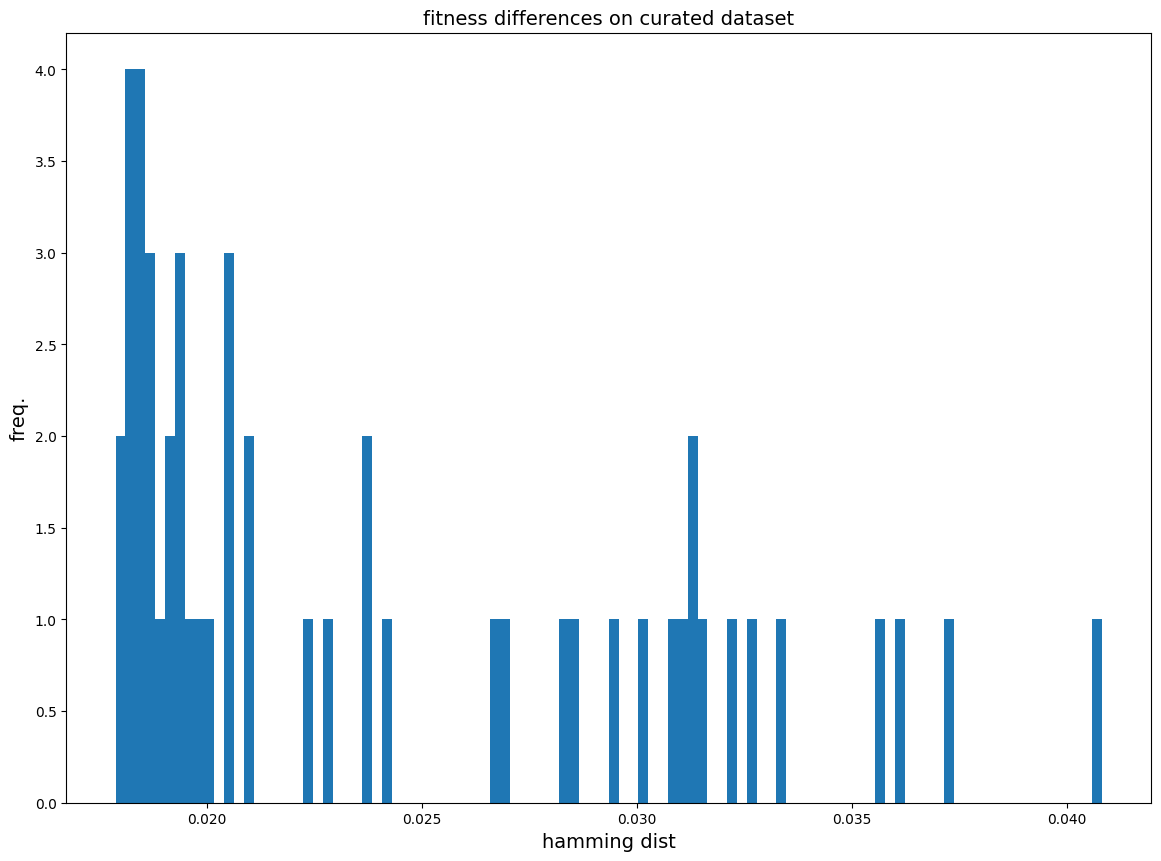

In [167]:
curated_fit_diffs = (output_logits[clean_tok_idxs, logit_id] - output_logits[corr_tok_idxs, logit_id]).cpu().numpy()
print("min fitness diff: %.4f"%curated_fit_diffs.min(), "\nmax fitness diff: %.4f"%curated_fit_diffs.max(), "\naverage fitness diff: %.4f"%(curated_avg_fitness.item()))
fig,ax = plt.subplots(1,1,figsize=(14,10))
ax.hist(curated_fit_diffs, bins=100)
ax.set_title("fitness differences on curated dataset", fontsize=14)
ax.set_ylabel("freq.", fontsize=14)
ax.set_xlabel("hamming dist", fontsize=14)
plt.show()

# Re-running patching experiments

## Regressor on different resid streams

In [168]:
clean_toks = tok_seqs[clean_tok_idxs,:]
corr_toks = tok_seqs[corr_tok_idxs,:]

In [169]:
resid_component_names = ["blocks.0.hook_resid_pre"]
for layer in range(hooked_esm.cfg.n_layers):
    resid_mid_name = f"blocks.{layer}.hook_resid_mid"
    resid_post_name = f"blocks.{layer}.hook_resid_post"
    resid_component_names.append(resid_mid_name)
    resid_component_names.append(resid_post_name)
    
def patch_resid_direct_to_regressor(toks: Float[Tensor, "n_data d_vocab"], model, logit_id=logit_id, resid_component_names=resid_component_names):
    n_data = toks.size(0)
    _, resid_cache = model.run_with_cache(toks, names_filter=resid_component_names)
    torch.cuda.empty_cache()

    logit_results = torch.zeros(n_data, len(resid_component_names)).to(device) #[n_data n_components]
    final_ln = model.ln_final

    # run regressor model on residual stream at each layer (including before attn0 and after final layer norm)
    for i, component in enumerate(resid_component_names):
        resid_component = final_ln(resid_cache[component])
        logit_results[:, i] = get_logit_hooked(resid_component, tok_id=logit_id)

    return logit_results

In [170]:
clean_resid_layer_results = patch_resid_direct_to_regressor(clean_toks, hooked_esm)
torch.cuda.empty_cache()
corr_resid_layer_results = patch_resid_direct_to_regressor(corr_toks, hooked_esm)
torch.cuda.empty_cache()

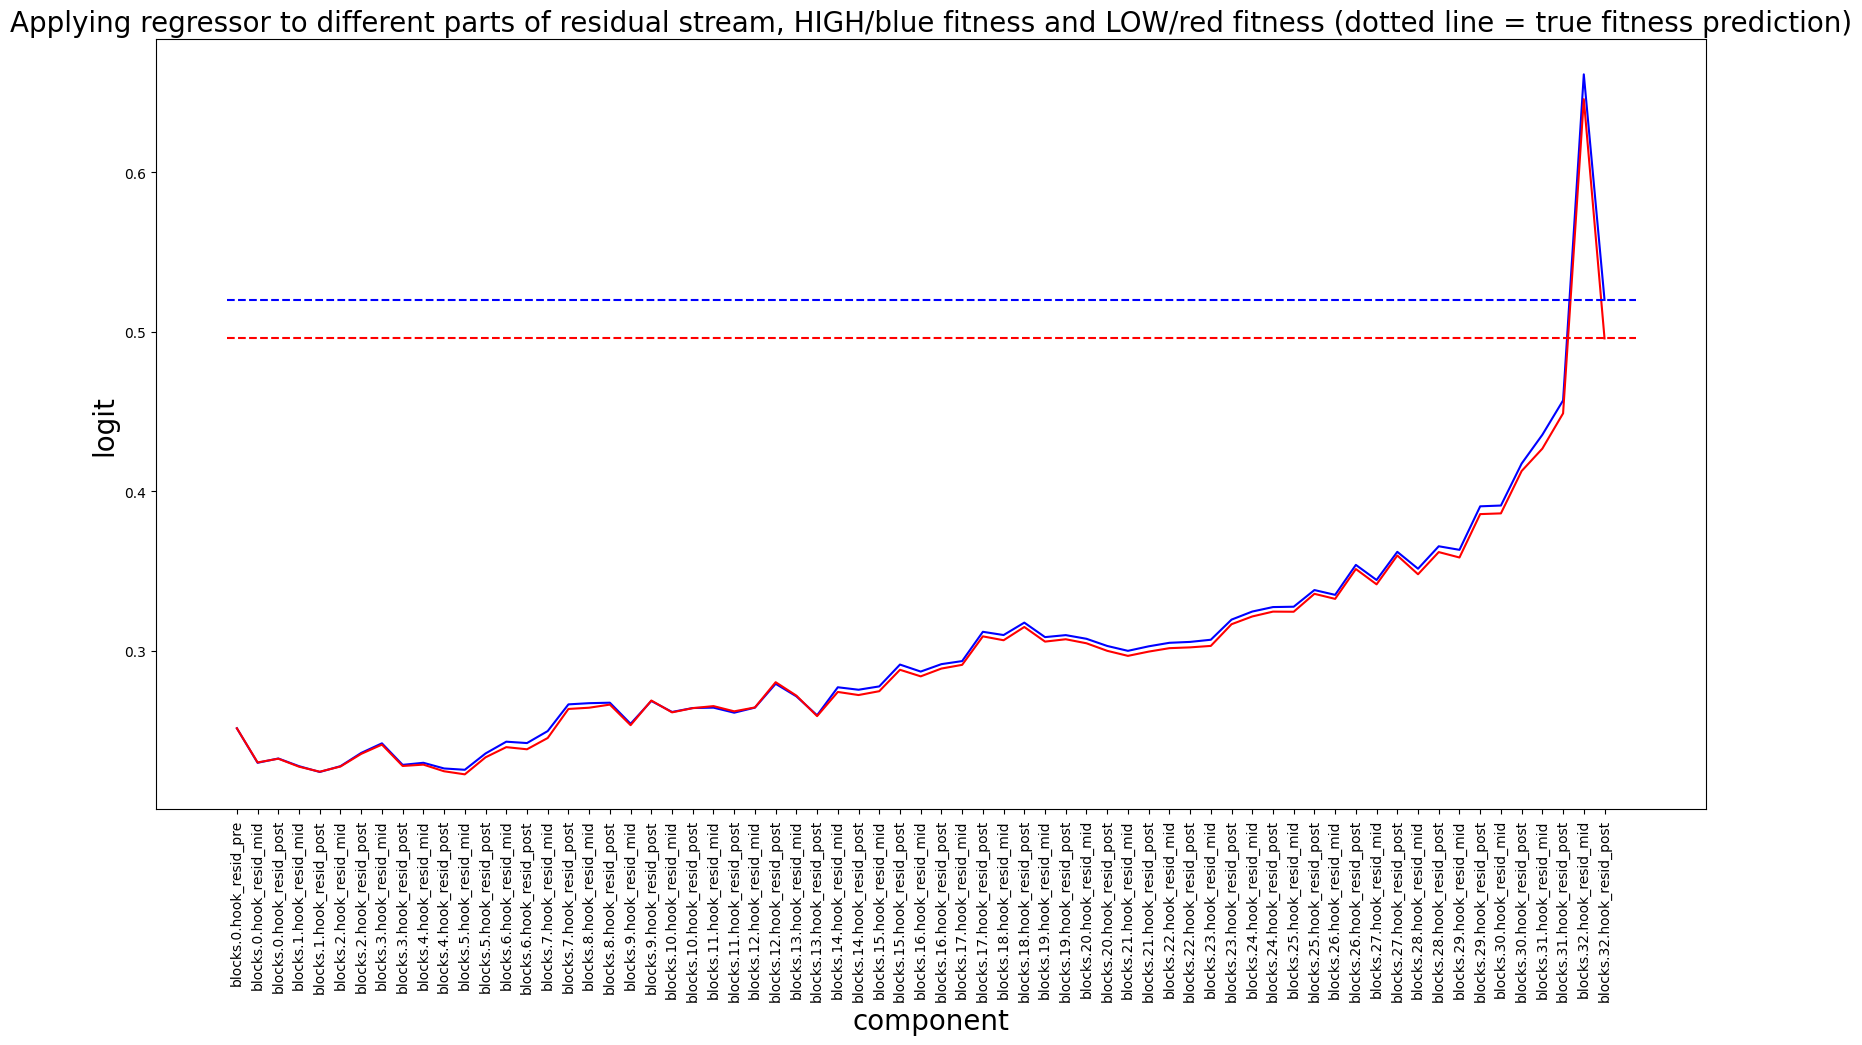

In [171]:
# display results
fig, ax = plt.subplots(1,1,figsize=(20,10))
ax.plot(list(range(len(resid_component_names))), clean_resid_layer_results.mean(dim=0).cpu().numpy(), color="blue")
ax.plot(list(range(len(resid_component_names))), corr_resid_layer_results.mean(dim=0).cpu().numpy(), color="red")

ax.plot([-0.5, len(resid_component_names)+0.5], [output_logits[clean_tok_idxs,logit_id].mean(dim=0).cpu().numpy() for _ in range(2)], linestyle="dashed", color="blue")
ax.plot([-0.5, len(resid_component_names)+0.5], [output_logits[corr_tok_idxs,logit_id].mean(dim=0).cpu().numpy() for _ in range(2)], linestyle="dashed", color="red")

ax.set_title("Applying regressor to different parts of residual stream, HIGH/blue fitness and LOW/red fitness (dotted line = true fitness prediction)", fontsize=20)
ax.set_xticks(list(range(len(resid_component_names))), resid_component_names, rotation="vertical")
ax.set_xlabel("component", fontsize=20)
ax.set_ylabel("logit", fontsize=20)
plt.show()

In [172]:
fit_mean_diff_high_low = output_logits[clean_tok_idxs,logit_id].mean(dim=0).cpu().numpy() - output_logits[corr_tok_idxs,logit_id].mean(dim=0).cpu().numpy() 

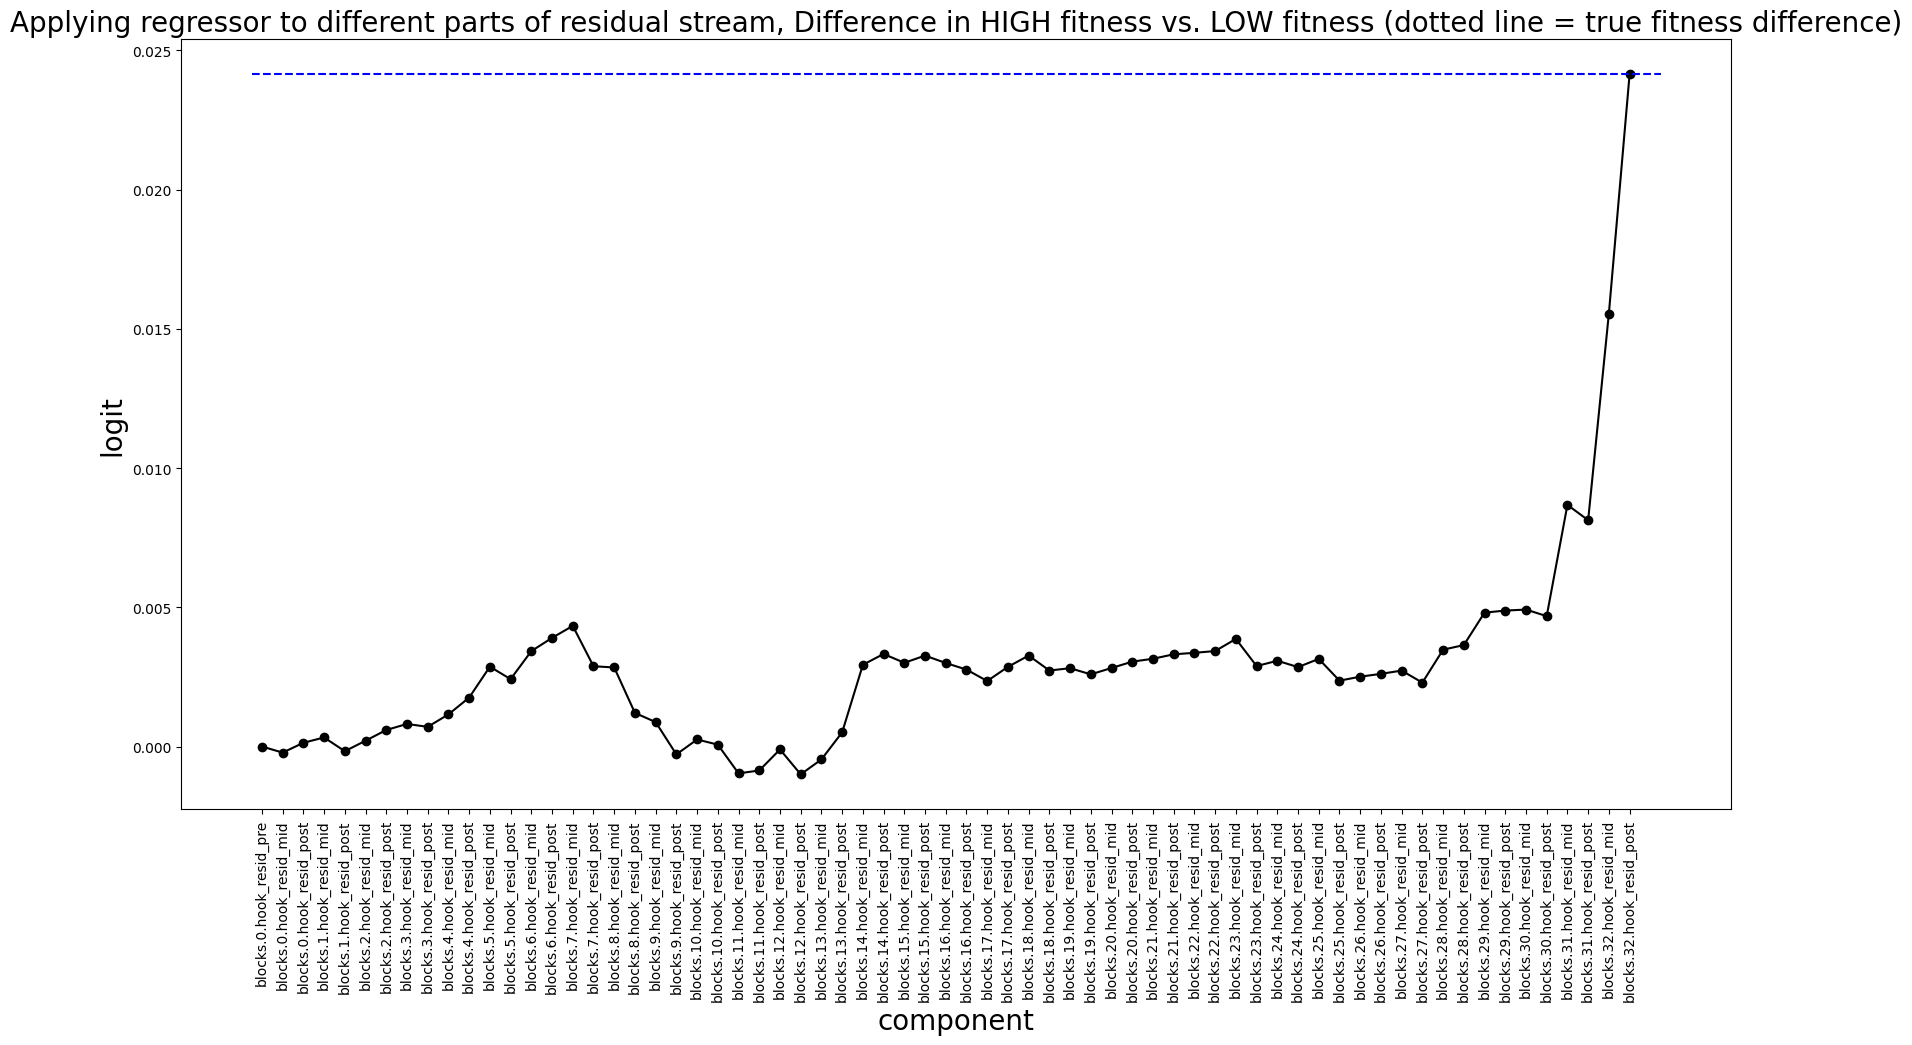

In [173]:
# display results
fig, ax = plt.subplots(1,1,figsize=(20,10))
ax.plot(list(range(len(resid_component_names))), clean_resid_layer_results.mean(dim=0).cpu().numpy() - corr_resid_layer_results.mean(dim=0).cpu().numpy(), color="black")
ax.scatter(list(range(len(resid_component_names))), clean_resid_layer_results.mean(dim=0).cpu().numpy() - corr_resid_layer_results.mean(dim=0).cpu().numpy(), color="black")

ax.plot([-0.5, len(resid_component_names)+0.5], [fit_mean_diff_high_low for _ in range(2)], linestyle="dashed", color="blue")

ax.set_title("Applying regressor to different parts of residual stream, Difference in HIGH fitness vs. LOW fitness (dotted line = true fitness difference)", fontsize=20)
ax.set_xticks(list(range(len(resid_component_names))), resid_component_names, rotation="vertical")
ax.set_xlabel("component", fontsize=20)
ax.set_ylabel("logit", fontsize=20)
plt.show()

# Examining role of L32H8 on layer 32 effect

### What we eventually find is that L32H8 has the largest degradation when exlcuded and the largest boost when included of the heads in layer 32

In [174]:
L32H8_resid_filter = ["blocks.32.attn.hook_z", *resid_component_names[-3:]]
_, clean_L32H8_resid_cache = hooked_esm.run_with_cache(clean_toks, names_filter=L32H8_resid_filter)
torch.cuda.empty_cache()
_, corr_L32H8_resid_cache = hooked_esm.run_with_cache(corr_toks, names_filter=L32H8_resid_filter)
torch.cuda.empty_cache()

In [175]:
def get_L32H8_dummy_real(seq_toks, L32H8_resid_cache,head_range: List[Int] | Int):
    # creating dummy attn output only using output of L32H8
    dummy_L32H8_z = torch.zeros(seq_toks.shape[0], seq_toks.shape[1], hooked_esm.cfg.n_heads, hooked_esm.cfg.d_head).to(device) #[batch pos n_head d_head]
    dummy_L32H8_z[:,:,head_range,:] = L32H8_resid_cache["blocks.32.attn.hook_z"][:,:,head_range,:] # assign "z" of L32H8 to dummy z and keep all other heads as 0
    dummy_L32H8_output = einops.einsum(hooked_esm.W_O[32,:,:,:], dummy_L32H8_z, "n_head d_head d_model, batch pos n_head d_head -> batch pos d_model") + hooked_esm.b_O[32]
    
    # used for computing mlp output
    mlp32_ln2 = hooked_esm.blocks[32].ln2
    mlp32_comp = hooked_esm.blocks[32].mlp
    
    dummy_resid32_mid = dummy_L32H8_output + L32H8_resid_cache["blocks.31.hook_resid_post"]
    dummy_L32H8_mlp_output = mlp32_comp(mlp32_ln2(dummy_resid32_mid))
    dummy_resid32_post = dummy_L32H8_mlp_output + dummy_resid32_mid
    
    dummy_L32_resid_streams = [L32H8_resid_cache["blocks.31.hook_resid_post"], dummy_resid32_mid, dummy_resid32_post]
    real_L32_resid_stream = [L32H8_resid_cache[comp_name] for comp_name in resid_component_names[-3:]]

    return dummy_L32_resid_streams, real_L32_resid_stream

def patch_streams_direct_to_regressor(model, resid_stream_list: List[Tensor], logit_id=logit_id):
    n_data = resid_stream_list[0].shape[0]
    final_ln = model.ln_final

    logit_results = torch.zeros(n_data, len(resid_stream_list)).to(device) #[n_data n_components]
    
    # run regressor model on residual stream at each layer (including before attn0 and after final layer norm)
    for i, resid_stream in enumerate(resid_stream_list):
        resid_component = final_ln(resid_stream)
        logit_results[:, i] = get_logit_hooked(resid_component, tok_id=logit_id)

    return logit_results

In [176]:
including_head_data = []
excluding_head_data = []
for i in tqdm(range(20)):
    # EXCLUDING ith head 
    exclude_head_idx = [j for j in range(20) if j != i]
    clean_dummy_L32_resid_streams, clean_real_L32_resid_stream = get_L32H8_dummy_real(clean_toks, clean_L32H8_resid_cache, exclude_head_idx)
    corr_dummy_L32_resid_streams, corr_real_L32_resid_stream = get_L32H8_dummy_real(corr_toks, corr_L32H8_resid_cache, exclude_head_idx)
    
    clean_dummy_L32_logits = patch_streams_direct_to_regressor(hooked_esm, clean_dummy_L32_resid_streams)
    clean_real_L32_logits = patch_streams_direct_to_regressor(hooked_esm, clean_real_L32_resid_stream)
    
    corr_dummy_L32_logits = patch_streams_direct_to_regressor(hooked_esm, corr_dummy_L32_resid_streams)
    corr_real_L32_logits = patch_streams_direct_to_regressor(hooked_esm, corr_real_L32_resid_stream)
    excluding_head_data.append(clean_dummy_L32_logits.mean(dim=0).detach().cpu().numpy() - corr_dummy_L32_logits.mean(dim=0).detach().cpu().numpy())
    del exclude_head_idx

    # INCLUDING only ith head
    include_head_idx = i
    clean_dummy_L32_resid_streams, clean_real_L32_resid_stream = get_L32H8_dummy_real(clean_toks, clean_L32H8_resid_cache, include_head_idx)
    corr_dummy_L32_resid_streams, corr_real_L32_resid_stream = get_L32H8_dummy_real(corr_toks, corr_L32H8_resid_cache, include_head_idx)
    
    clean_dummy_L32_logits = patch_streams_direct_to_regressor(hooked_esm, clean_dummy_L32_resid_streams)
    clean_real_L32_logits = patch_streams_direct_to_regressor(hooked_esm, clean_real_L32_resid_stream)
    
    corr_dummy_L32_logits = patch_streams_direct_to_regressor(hooked_esm, corr_dummy_L32_resid_streams)
    corr_real_L32_logits = patch_streams_direct_to_regressor(hooked_esm, corr_real_L32_resid_stream)
    including_head_data.append(clean_dummy_L32_logits.mean(dim=0).detach().cpu().numpy() - corr_dummy_L32_logits.mean(dim=0).detach().cpu().numpy())

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:04<00:00,  4.20it/s]


In [177]:
fit_mean_diff_high_low = output_logits[clean_tok_idxs,logit_id].mean(dim=0).cpu().numpy() - output_logits[corr_tok_idxs,logit_id].mean(dim=0).cpu().numpy() 

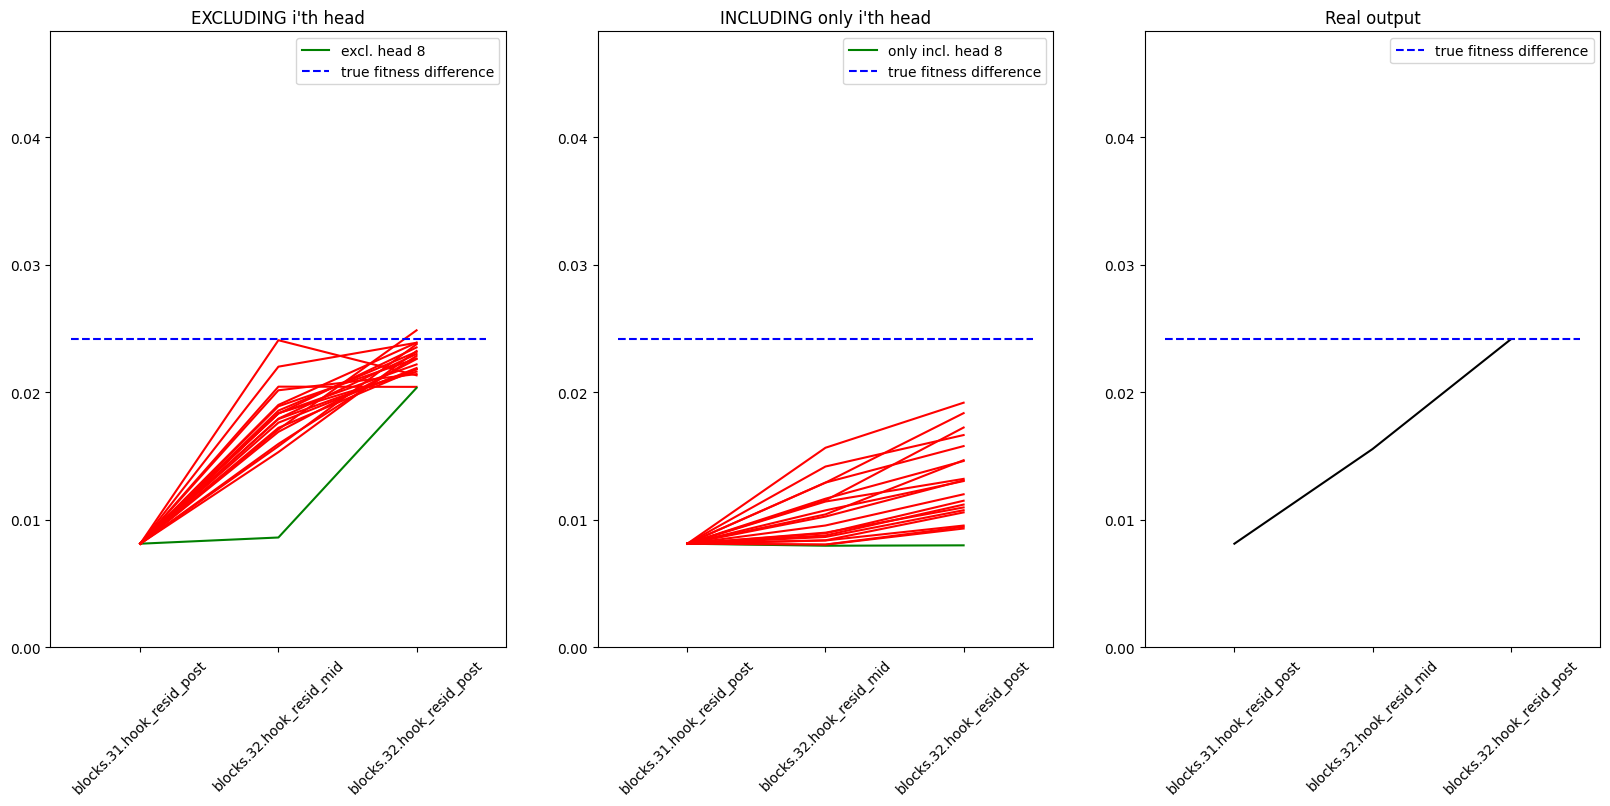

In [178]:
fig, ax = plt.subplots(1,3,figsize=(20,8))
ax[0].set_title(f"EXCLUDING i'th head")
for i,ex_head_data in enumerate(excluding_head_data):
    if i != 8:
        ax[0].plot(list(range(3)), ex_head_data, color="red")
    else:
        ax[0].plot(list(range(3)), ex_head_data, label="excl. head 8", color="green")
    ax[0].set_xticks(list(range(3)), resid_component_names[-3:], rotation=45)
    ax[0].set_ylim(0,fit_mean_diff_high_low * 2)
ax[0].plot([-0.5, 2+0.5], [fit_mean_diff_high_low for _ in range(2)], linestyle="dashed", color="blue", label="true fitness difference")
ax[0].legend()

ax[1].set_title(f"INCLUDING only i'th head")
for i,in_head_data in enumerate(including_head_data):
    if i != 8:
        ax[1].plot(list(range(3)), in_head_data, color="red")
    else:
        ax[1].plot(list(range(3)), in_head_data, label="only incl. head 8", color="green")
    ax[1].set_xticks(list(range(3)), resid_component_names[-3:], rotation=45)
    ax[1].set_ylim(0,fit_mean_diff_high_low * 2)
ax[1].plot([-0.5, 2+0.5], [fit_mean_diff_high_low for _ in range(2)], linestyle="dashed", color="blue", label="true fitness difference")
ax[1].legend()

ax[-1].set_title("Real output")
ax[-1].plot(list(range(3)), clean_real_L32_logits.mean(dim=0).detach().cpu().numpy() - corr_real_L32_logits.mean(dim=0).detach().cpu().numpy(), color="black")
ax[-1].plot([-0.5, 2+0.5], [fit_mean_diff_high_low for _ in range(2)], linestyle="dashed", color="blue", label="true fitness difference")
ax[-1].legend()
ax[-1].set_xticks(list(range(3)), resid_component_names[-3:], rotation=45)
ax[-1].set_ylim(0,fit_mean_diff_high_low * 2)

plt.show()

## Path patching

In [179]:
def path_patching_metric(
    logits: Float[Tensor, "batch"],
    corrupted_logit_mean: float,
    clean_logit_mean: float,
):
    """
    Equals 0 when performance is conserved (i.e. high fitness sequences still high fitness)
    Equals -1 when performance is destroyed (high fitness sequence is degraded)
    """

    return ((logits - clean_logit_mean) / (clean_logit_mean - corrupted_logit_mean)).mean().item()

In [180]:
# hooks functions
def patch_or_freeze_head_vectors(
    orig_head_vector: Float[Tensor, "batch pos head_index d_head"],
    hook: HookPoint,
    new_cache: ActivationCache,
    orig_cache: ActivationCache,
    head_to_patch: tuple[int, int], # [layer, head]
) -> Float[Tensor, "batch pos head_index d_head"]:
    """
    This helps implement step 2 of path patching. We freeze all head outputs (i.e. set them to their
    values in orig_cache), except for head_to_patch (if it's in this layer) which we patch with the
    value from new_cache.

    head_to_patch: tuple of (layer, head)
    """
    # Setting using ..., otherwise changing orig_head_vector will edit cache value too
    orig_head_vector[...] = orig_cache[hook.name][...]
    if head_to_patch[0] == hook.layer():
        orig_head_vector[:, :, head_to_patch[1]] = new_cache[hook.name][:, :, head_to_patch[1]]
    return orig_head_vector


def patch_head_input(
    orig_activation: Float[Tensor, "batch pos head_idx d_head"],
    hook: HookPoint,
    patched_cache: ActivationCache,
    head_list: list[tuple[int, int]],
) -> Float[Tensor, "batch pos head_idx d_head"]:
    """
    Function which can patch any combination of heads in layers,
    according to the heads in head_list.
    """
    heads_to_patch = [head for layer, head in head_list if layer == hook.layer()]
    orig_activation[:, :, heads_to_patch] = patched_cache[hook.name][:, :, heads_to_patch]
    return orig_activation


    

# result functions
def get_path_patch_head_to_final_resid_post(
    model: HookedTransformer,
    patching_metric: Callable,
    new_dataset: Float[Tensor, "batch pos"],
    orig_dataset: Float[Tensor, "batch pos"],
    new_cache: ActivationCache | None,
    orig_cache: ActivationCache | None,
    logit_id=logit_id
) -> Float[Tensor, "layer head"]:
    """
    Performs path patching (see algorithm in appendix B of IOI paper), with:

        sender head = (each head, looped through, one at a time)
        receiver node = final value of residual stream

    Returns:
        tensor of metric values for every possible sender head
    """


    num_layers = model.cfg.n_layers
    num_heads = model.cfg.n_heads

    results = torch.zeros((num_layers, num_heads)).to(model.cfg.device)

    resid_post_name = "unembed.hook_out"
    resid_filter = lambda x: x == resid_post_name
    z_name_filter = lambda name: name.endswith("z")

    # step 1, get cached runs
    if new_cache == None:
        _, new_cache = model.run_with_cache(new_dataset, names_filter=z_name_filter)
        torch.cuda.empty_cache()

    if orig_cache == None:
        _, orig_cache = model.run_with_cache(orig_dataset, names_filter=z_name_filter)
        torch.cuda.empty_cache()

    with tqdm(total = num_layers * num_heads) as fancy_progress_bar:
        for layer in range(num_layers):
            for head in range(num_heads):
                model.reset_hooks()
    
                # step 2, run original dataset with non-direct paths frozen
                partial_hook_f = functools.partial(patch_or_freeze_head_vectors, new_cache=new_cache, orig_cache=orig_cache, head_to_patch=(layer, head))
                model.add_hook(z_name_filter, partial_hook_f, dir="fwd")
                _, resid_cache = model.run_with_cache(orig_dataset, names_filter=resid_filter)
    
                # step 3, compute final logits
                path_patched_logits = get_logit_hooked(resid_cache[resid_post_name], logit_id)
                torch.cuda.empty_cache()
    
                results[layer, head] = patching_metric(path_patched_logits)
                fancy_progress_bar.update()

    model.reset_hooks()
    return results
    

def get_path_patch_head_to_heads(
    model: HookedTransformer,
    receiver_heads: list[tuple[int, int]], # (layer,head)
    receiver_input: str,
    new_dataset: Float[Tensor, "batch pos"],
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache: ActivationCache | None,
    orig_cache: ActivationCache | None,
) -> Float[Tensor, "layer head"]:
    """
    Performs path patching (see algorithm in appendix B of IOI paper), with:

        sender head = (each head, looped through, one at a time)
        receiver node = input to a later head (or set of heads)

    The receiver node is specified by receiver_heads and receiver_input, for example if
    receiver_input = "v" and receiver_heads = [(8, 6), (8, 10), (7, 9), (7, 3)], we're doing path
    patching from each head to the value inputs of the S-inhibition heads.

    Returns:
        tensor of metric values for every possible sender head
    """

    num_layers = model.cfg.n_layers
    num_heads = model.cfg.n_heads

    results = torch.zeros((num_layers, num_heads)).to(model.cfg.device)
    z_name_filter = lambda name: name.endswith("z")

    receiver_layers = set([x[0] for x in receiver_heads])
    receiver_hook_names = [utils.get_act_name(receiver_input, layer) for layer in receiver_layers]
    receiver_hook_names_filter = lambda name: name in receiver_hook_names

    # step 1, get cached runs
    if new_cache == None:
        _, new_cache = model.run_with_cache(new_dataset, names_filter=z_name_filter)
        torch.cuda.empty_cache()

    if orig_cache == None:
        _, orig_cache = model.run_with_cache(orig_dataset, names_filter=z_name_filter)
        torch.cuda.empty_cache()

    with tqdm(total = num_layers * num_heads) as fancy_progress_bar:
        for layer in range(num_layers):
            for head in range(num_heads):
                model.reset_hooks()
    
                # step 2, run original dataset with non-direct paths frozen
                step2_hook_f = functools.partial(patch_or_freeze_head_vectors, new_cache=new_cache, orig_cache=orig_cache, head_to_patch=(layer, head))
                model.add_hook(z_name_filter, step2_hook_f, dir="fwd")
                _, patching_cache = model.run_with_cache(orig_dataset, names_filter=receiver_hook_names_filter)
                torch.cuda.empty_cache()
    
                # step 3, compute final logits
                model.reset_hooks()
                step3_hook_f = functools.partial(patch_head_input, patched_cache=patching_cache, head_list=receiver_heads)
                path_patched_logits_esm = model.run_with_hooks(orig_dataset, fwd_hooks=[(receiver_hook_names_filter, step3_hook_f)], return_type="logits")
                path_patched_logits = get_logit_hooked(path_patched_logits_esm, logit_id)
                torch.cuda.empty_cache()
    
                results[layer, head] = patching_metric(path_patched_logits)
                fancy_progress_bar.update()
    model.reset_hooks()
    return results

In [181]:
hooked_esm.reset_hooks(including_permanent=False)
# original = high fitness
# new = low fitness

corrupted_logit_mean = get_logit_hooked(hooked_esm(corr_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.024142593145370483


In [182]:
# cache attention outputs
_, orig_cache = hooked_esm.run_with_cache(clean_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()
_, new_cache = hooked_esm.run_with_cache(corr_toks, names_filter=lambda name: name.endswith("z"))
torch.cuda.empty_cache()

In [35]:
path_patch_head_to_final_resid_post = get_path_patch_head_to_final_resid_post(
    hooked_esm, 
    functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
    
    orig_dataset=clean_toks, # high fitness
    new_dataset=corr_toks, # low fitness

    orig_cache=orig_cache,
    new_cache=new_cache, 
    
    logit_id=logit_id
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 660/660 [33:43<00:00,  3.07s/it]


In [199]:
imshow(
    path_patch_head_to_final_resid_post.T,
    labels={"x": "Layer", "y": "Head", "color": "Rel. change in fitness"},
    title="Path patching change in fitness LOW into HIGH (0 = conserved, -1 = destroyed)",
    width=1200,
    height=800,
    range_color=(-0.3,0.3)
)

# Absolute path patching

In [198]:
# direct to resid stream
def path_patch_head_absolute_direct(
    model,
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache,
    logit_id,
) -> Float[Tensor, "num_layer num_head"]:

    num_layers = model.cfg.n_layers
    num_heads = hooked_esm.cfg.n_heads
    path_path_results = torch.zeros(num_layers, num_heads)

    z_name_list = [f"blocks.{layer}.attn.hook_z" for layer in range(num_layers)]
    names_filter = ["blocks.32.hook_resid_post", *z_name_list]
    _, orig_cache = hooked_esm.run_with_cache(orig_dataset, names_filter=names_filter)

    esm_output = orig_cache["blocks.32.hook_resid_post"] # [batch pos d_model]
    final_ln = hooked_esm.ln_final
    
    torch.cuda.empty_cache()
    
    with tqdm(total = num_layers * num_heads) as fancy_progress_bar:
        for layer in range(num_layers):
            W_O_layer = hooked_esm.W_O[layer] # [n_head d_head d_model]
            b_O_layer = hooked_esm.b_O[layer]
 
            for head in range(num_heads):
                head_name = f"blocks.{layer}.attn.hook_z"
                layer_head_output_orig = einops.einsum(orig_cache[head_name], W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]

                layer_head_z_new = orig_cache[head_name].detach().clone() # [batch pos n_head d_head]
                layer_head_z_new[:,:,head,:] = new_cache[head_name][:,:,head,:]
                layer_head_output_new = einops.einsum(layer_head_z_new, W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]

                path_patched_logit = final_ln(esm_output - layer_head_output_orig + layer_head_output_new)
                # step 3, compute final logits
                path_patched_logits = get_logit_hooked(path_patched_logit, logit_id)
                torch.cuda.empty_cache()
        
                path_path_results[layer, head] = patching_metric(path_patched_logits)
                
                fancy_progress_bar.update()

    return path_path_results


def path_patch_mlp_absolute_direct(
    model,
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache,
    logit_id=logit_id,
) -> Float[Tensor, "num_layer num_head"]:

    num_layers = model.cfg.n_layers
    path_patch_results = torch.zeros(num_layers).to(device)

    mlp_names_filter = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]
    names_filter = ["blocks.32.hook_resid_post", *mlp_names_filter]
    _, orig_cache = hooked_esm.run_with_cache(orig_dataset, names_filter=names_filter)

    esm_output = orig_cache["blocks.32.hook_resid_post"] # [batch pos d_model]
    final_ln = hooked_esm.ln_final
    
    torch.cuda.empty_cache()
    
    with tqdm(total = num_layers * 1) as fancy_progress_bar:
        for layer in range(num_layers):
            mlp_name = mlp_names_filter[layer] 
            mlp_orig_output = orig_cache[mlp_name] # [batch pos d_model]
            mlp_new_output = new_cache[mlp_name] # [batch pos d_model]

            path_patched_logit = final_ln(esm_output - mlp_orig_output + mlp_new_output) # [batch pos d_model]
            # step 3, compute final logits
            path_patched_logits = get_logit_hooked(path_patched_logit, tok_id=logit_id) # [batch]
            path_patch_results[layer] = patching_metric(path_patched_logits)
            torch.cuda.empty_cache()
            fancy_progress_bar.update()

    return path_patch_results




# abs patch to attn. or MLP 
# hook functions
def abs_path_patch_head_input(
    orig_head_vector: Float[Tensor, "batch pos n_head d_head"],
    hook: HookPoint,
    new_comp: Float[Tensor, "batch pos d_head"], # changed_head_vector at head_idx
    head_idx: int
):
    orig_head_vector[:,:,head_idx,:] = new_comp
    return orig_head_vector


def abs_path_patch_mlp_input(
    orig_mlp_vector: Float[Tensor, "batch pos d_mlp"],
    hook: HookPoint,
    new_comp: Float[Tensor, "batch pos d_mlp"], # changed_mlp_vector
):
    orig_mlp_vector[...] = new_comp[...]
    return orig_mlp_vector


# actual functions
def abs_path_patch_receiver_heads(
    model: HookedTransformer,
    receiver_heads: list[tuple[int, int]], # (layer,head)
    receiver_input: str, #one of {"q", "k", "v"}
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache: ActivationCache, # cached attn. z
    orig_cache: ActivationCache, # cached attn. z
) -> Float[Tensor, "num_layer num_head"]:

    num_layers = model.cfg.n_layers
    num_heads = hooked_esm.cfg.n_heads
    path_patch_results = torch.zeros(num_layers, num_heads)

    # inputs to receiver head are output of prev layer
    receiver_layer_inputs = [x[0] - 1 for x in receiver_heads]

    # receiver head layers
    receiver_layers = [x[0] for x in receiver_heads]
    
    layer_head_lns = [model.blocks[layer].ln1 for layer in receiver_layers]
    resid_post_names = [f"blocks.{layer}.hook_resid_post" for layer in receiver_layer_inputs]
    _, resid_post_cache = model.run_with_cache(high_toks, names_filter = resid_post_names)
    torch.cuda.empty_cache()

    W_receiver = {"q": model.W_Q, "k": model.W_K, "v": model.W_V}[receiver_input]
    b_receiver = {"q": model.b_Q, "k": model.b_K, "v": model.b_V}[receiver_input]
    
    with tqdm(total = max(receiver_layers) * num_heads) as fancy_progress_bar:
        for layer in range(max(receiver_layers)):
            W_O_layer = hooked_esm.W_O[layer] # [n_head d_head d_model]
            b_O_layer = hooked_esm.b_O[layer]
 
            for head in range(num_heads):
                model.reset_hooks()
                head_name = f"blocks.{layer}.attn.hook_z"

                # STEP 2
                # new_resid_input= old_resid_input - old_head_output + new_head_output
                # new_head_output
                new_head_z = orig_cache[head_name].detach().clone() # [batch pos n_head d_head]
                new_head_z[:,:, head, :] = new_cache[head_name][:,:,head,:] # [batch pos n_head d_head]
                new_head_output = einops.einsum(new_head_z, W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]
                # old_head_output
                orig_head_output = einops.einsum(orig_cache[head_name], W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]

                # add hooks (compute what the new component would've been using new_resid_input and patch that in using abs_path_patch_head_input)
                for r_ln, r_post_name, (rl, rh) in zip(layer_head_lns, resid_post_names, receiver_heads):
                    new_resid_input = r_ln(resid_post_cache[r_post_name] - orig_head_output + new_head_output)
                    new_comp = einops.einsum(new_resid_input, W_receiver[rl], "batch pos d_model, n_head d_model d_head -> batch pos n_head d_head") + b_receiver[rl] # [batch pos n_head d_head]
                    
                    model.add_hook(
                        utils.get_act_name(receiver_input, rl), 
                        functools.partial(abs_path_patch_head_input, new_comp=new_comp[:,:,rh,:], head_idx=rh), 
                        dir="fwd"
                    )
                
                path_patched_logits = model(orig_dataset) # [batch pos d_model]
                # step 3, compute final logits
                path_patched_logits = get_logit_hooked(path_patched_logits, logit_id)
                torch.cuda.empty_cache()
        
                path_patch_results[layer, head] = patching_metric(path_patched_logits)
                
                fancy_progress_bar.update()
        model.reset_hooks()
    return path_patch_results


def abs_path_patch_mlp_to_receiver_heads(
    model: HookedTransformer,
    receiver_heads: list[tuple[int, int]], # (layer,head)
    receiver_input: str, #one of {"q", "k", "v"}
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache: ActivationCache, # cached mlp
    orig_cache: ActivationCache, # cached mlp
) -> Float[Tensor, "num_layer num_head"]:

    num_layers = model.cfg.n_layers
    num_heads = hooked_esm.cfg.n_heads
    path_patch_results = torch.zeros(num_layers)

    # inputs to receiver head are output of prev layer
    receiver_layer_inputs = [x[0] - 1 for x in receiver_heads]

    # receiver head layers
    receiver_layers = [x[0] for x in receiver_heads]
    
    layer_head_lns = [model.blocks[layer].ln1 for layer in receiver_layers]
    resid_post_names = [f"blocks.{layer}.hook_resid_post" for layer in receiver_layer_inputs]
    _, resid_post_cache = model.run_with_cache(high_toks, names_filter = resid_post_names)
    torch.cuda.empty_cache()

    W_receiver = {"q": model.W_Q, "k": model.W_K, "v": model.W_V}[receiver_input]
    b_receiver = {"q": model.b_Q, "k": model.b_K, "v": model.b_V}[receiver_input]
    
    with tqdm(total = max(receiver_layers)) as fancy_progress_bar:
        for layer in range(max(receiver_layers)):
            model.reset_hooks()
            mlp_layer_name = f"blocks.{layer}.hook_mlp_out"

            # STEP 2
            # new_resid_input= old_resid_input - old_head_output + new_head_output
            # new_head_output
            new_mlp_output = new_cache[mlp_layer_name]
            # old_head_output
            orig_mlp_output = orig_cache[mlp_layer_name]

            # add hooks (compute what the new component would've been using new_resid_input and patch that in using abs_path_patch_head_input)
            for r_ln, r_post_name, (rl, rh) in zip(layer_head_lns, resid_post_names, receiver_heads):
                new_resid_input = r_ln(resid_post_cache[r_post_name] - orig_mlp_output + new_mlp_output)
                new_comp = einops.einsum(new_resid_input, W_receiver[rl], "batch pos d_model, n_head d_model d_head -> batch pos n_head d_head") + b_receiver[rl] # [batch pos n_head d_head]
                
                model.add_hook(
                    utils.get_act_name(receiver_input, rl), 
                    functools.partial(abs_path_patch_head_input, new_comp=new_comp[:,:,rh,:], head_idx=rh), 
                    dir="fwd"
                )
            
            path_patched_logits = model(orig_dataset) # [batch pos d_model]
            # step 3, compute final logits
            path_patched_logits = get_logit_hooked(path_patched_logits, logit_id)
            torch.cuda.empty_cache()
    
            path_patch_results[layer] = patching_metric(path_patched_logits)
            
            fancy_progress_bar.update()
        model.reset_hooks()
    return path_patch_results


def abs_path_patch_to_mlp(
    model: HookedTransformer,
    receiver_mlps: list[int], # (layers)
    orig_dataset: Float[Tensor, "batch pos"],
    patching_metric: Callable,
    new_cache: ActivationCache, # cached attn. z
    orig_cache: ActivationCache, # cached attn. z
) -> Float[Tensor, "num_layer num_head"]:

    num_layers = model.cfg.n_layers
    num_heads = hooked_esm.cfg.n_heads
    path_patch_results = torch.zeros(num_layers, num_heads)
    
    layer_head_lns = [model.blocks[layer].ln2 for layer in receiver_mlps]
    resid_mid_names = [f"blocks.{layer}.hook_resid_mid" for layer in receiver_mlps]
    _, resid_mid_cache = model.run_with_cache(high_toks, names_filter = resid_mid_names)
    torch.cuda.empty_cache()

    W_mlp_in = model.W_in # [n_layer d_model d_mlp]
    b_mlp_in = model.b_in # # [n_layer d_mlp]
    
    with tqdm(total = (max(receiver_mlps) + 1) * num_heads) as fancy_progress_bar:
        for layer in range(max(receiver_mlps) + 1):
            W_O_layer = hooked_esm.W_O[layer] # [n_head d_head d_model]
            b_O_layer = hooked_esm.b_O[layer]
 
            for head in range(num_heads):
                model.reset_hooks()
                head_name = f"blocks.{layer}.attn.hook_z"

                # STEP 2
                # new_resid_input= old_resid_input - old_head_output + new_head_output
                # new_head_output
                new_head_z = orig_cache[head_name].detach().clone() # [batch pos n_head d_head]
                new_head_z[:,:, head, :] = new_cache[head_name][:,:,head,:] # [batch pos n_head d_head]
                new_head_output = einops.einsum(new_head_z, W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]
                # old_head_output
                orig_head_output = einops.einsum(orig_cache[head_name], W_O_layer, "batch pos n_head d_head, n_head d_head d_model -> batch pos d_model") + b_O_layer # [batch pos d_model]

                # add hooks (compute what the new component would've been using new_resid_input and patch that in using abs_path_patch_head_input)
                for r_ln, r_post_name, rl in zip(layer_head_lns, resid_mid_names, receiver_mlps):
                    # only patch in things from earlier layers (including current layer since MHA comes before MLP)
                    if rl >= layer:
                        receiver_mlp_name = f"blocks.{rl}.mlp.hook_pre"
                        new_resid_input = r_ln(resid_mid_cache[r_post_name] - orig_head_output + new_head_output)
                        new_comp = einops.einsum(new_resid_input, W_mlp_in[rl], "batch pos d_model, d_model d_mlp -> batch pos d_mlp") + b_mlp_in[rl] # [batch pos n_head d_head]
                        
                        model.add_hook(
                            receiver_mlp_name, 
                            functools.partial(abs_path_patch_mlp_input, new_comp=new_comp), 
                            dir="fwd"
                        )
                
                path_patched_logits = model(orig_dataset) # [batch pos d_model]
                # step 3, compute final logits
                path_patched_logits = get_logit_hooked(path_patched_logits, logit_id)
                torch.cuda.empty_cache()
        
                path_patch_results[layer, head] = patching_metric(path_patched_logits)
                
                fancy_progress_bar.update()
        model.reset_hooks()
    return path_patch_results

In [186]:
hooked_esm.reset_hooks(including_permanent=False)
# clean = high fitness
# corr = low fitness

corrupted_logit_mean = get_logit_hooked(hooked_esm(corr_toks), logit_id).mean().item()
clean_logit_mean = get_logit_hooked(hooked_esm(clean_toks), logit_id).mean().item()
print(corrupted_logit_mean - clean_logit_mean)
torch.cuda.empty_cache()

-0.024142593145370483


In [188]:
# only need attention info
_, new_cache = hooked_esm.run_with_cache(corr_toks, names_filter=lambda x: "hook_z" in x)
torch.cuda.empty_cache()

In [189]:
abs_patch_head = path_patch_head_absolute_direct(
    hooked_esm, 
    orig_dataset=clean_toks, 
    patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
    new_cache=new_cache,
    logit_id=logit_id
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 660/660 [00:07<00:00, 85.83it/s]


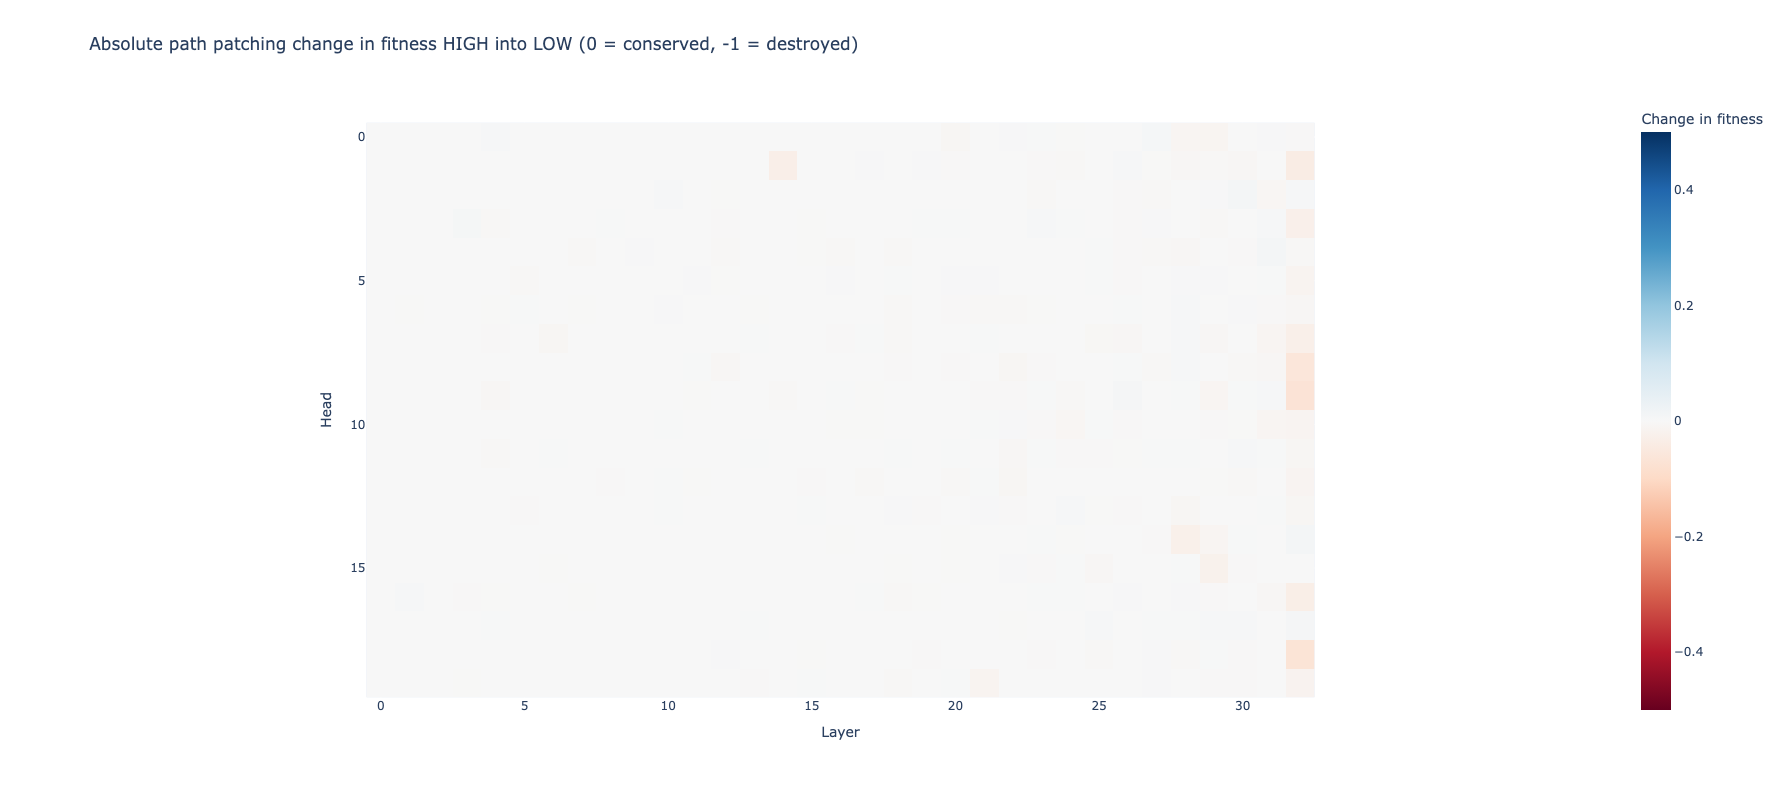

In [192]:
imshow(
    abs_patch_head.T,
    labels={"x": "Layer", "y": "Head", "color": "Change in fitness"},
    title="Absolute path patching change in fitness HIGH into LOW (0 = conserved, -1 = destroyed)",
    width=1200,
    height=800,
    range_color=(-0.5,0.5)
)

In [194]:
all_mlp_names = [f"blocks.{layer}.hook_mlp_out" for layer in range(hooked_esm.cfg.n_layers)]
# only need mlp info
_, new_cache = hooked_esm.run_with_cache(corr_toks, names_filter=all_mlp_names)
torch.cuda.empty_cache()

In [195]:
absolute_path_patch_mlp_results = path_patch_mlp_absolute_direct(
    hooked_esm,
    orig_dataset=clean_toks,
    patching_metric=functools.partial(path_patching_metric, corrupted_logit_mean=corrupted_logit_mean, clean_logit_mean=clean_logit_mean),
    new_cache=new_cache
)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 33/33 [00:00<00:00, 541.22it/s]


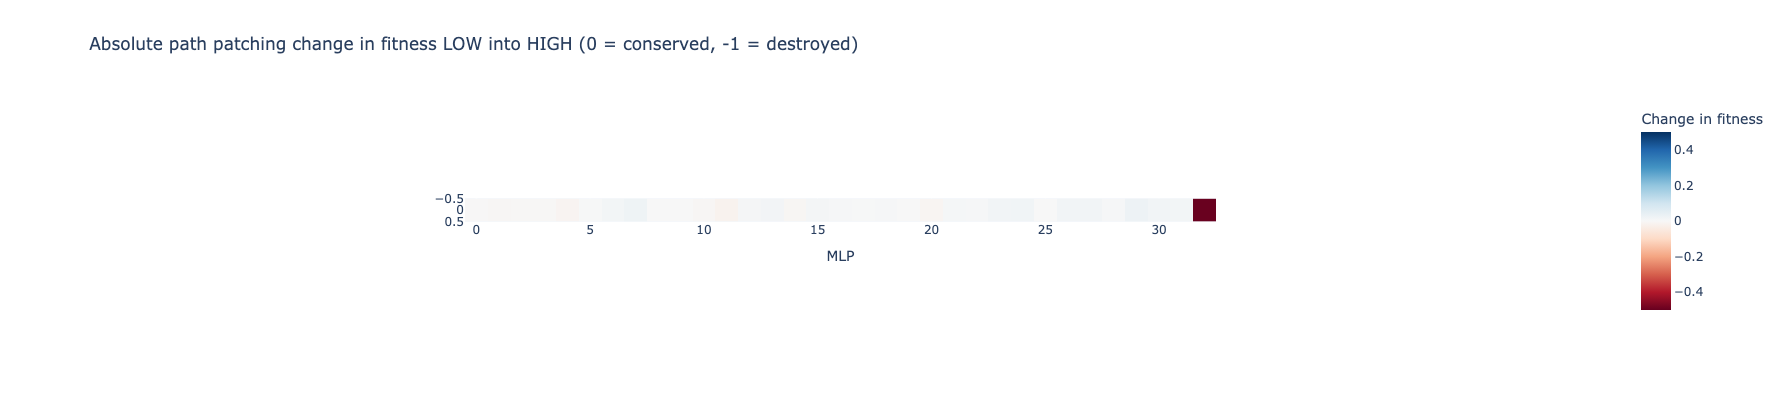

In [197]:
imshow(
    absolute_path_patch_mlp_results[None,:],
    labels={"x": "MLP", "y": "", "color": "Change in fitness"},
    title="Absolute path patching change in fitness LOW into HIGH (0 = conserved, -1 = destroyed)",
    width=1000,
    height=400,
    range_color=(-0.5,0.5)
)